# 11 – Erottuvuus teemoittain

**Tehtävä:** erottuvatko puolueet toisistaan myös silloin, kun ne puhuvat samasta aiheesta? Vertailu Gronowin ja Malkamäen (2024) Twitter-tulokseen.

**Miksi:** kasvava erottuvuus (muistio 05) voi johtua kahdesta eri asiasta:
- puolueet puhuvat **eri asioista** (aiheiden omistajuus, *issue ownership*), tai
- puolueet puhuvat **samasta asiasta eri tavalla** (kehystys, *framing*), mikä on lähempänä polarisaatiota.

Kun erottuvuus lasketaan vain yhtä teemaa käsittelevistä puheista, kaikki puolueet puhuvat samasta aiheesta. Silloin aiheen valinta ei voi selittää eroja. Gentzkow ym. (2019, s. 1326) erottelevat samalla tavalla aiheiden sisäisen ja niiden välisen eron (*within- and between-topic partisanship*); heillä aiheet määritellään fraaseina, meillä puheina.

**Syöte:**
- `Data/processed/party_oof.parquet` ja `party_nostyle_oof.parquet`: puhekohtaiset testiennusteet muistiosta 05
- `Data/processed/speeches_raw.parquet`: puheiden alkuperäinen teksti hakusanoja varten

**Tulokset:**
- `results/teemat_puheet.csv`: teemapuheiden määrät
- `results/teemat_pairwise.csv`: parien erottuvuus teemoittain
- `reports/figures/teemat_erottuvuus.png`

## Menetelmä

**Teemat.** Hakusanat ovat Gronowin ja Malkamäen (2024) liitteen taulukosta A1: maahanmuutto, ilmasto, korona, turvallisuus ja eriarvoisuus. Hakusana on sanan alku tai osa, ja se etsitään puheen tekstistä pienillä kirjaimilla (*substring match*), kuten alkuperäisessä tutkimuksessa. Puhe kuuluu teemaan, jos siinä on **vähintään kaksi osumaa**; yksi osuma on usein ohimenevä maininta. Puhe voi kuulua useaan teemaan.

Kolme hakusanaa on tehty Twitter-aineistoon, ja eduskuntapuheissa ne osuvat enimmäkseen muihin sanoihin (tarkistettu 40 000 puheen otoksesta). Ne rajataan sanan alkuun:

| hakusana | väärät osumat | muutos |
|---|---|---|
| *matu* | omatunto, raamatun, pääomatulot | vain sanan alussa |
| *rikka* | afrikka | vain sanan alussa |
| *krim* | kriminalisointi, kriminaalipolitiikka | vain sanan alussa, ei *kriminaal-* eikä *kriminalis-* |

Eriarvoisuusteeman hakusanoista *vero* tuottaa suurimman osan osumista, joten teema on eduskunnassa lähinnä verokeskustelua. Tulos raportoidaan varauksin.

**Erottuvuus.** Käytetään muistion 05 päämallin ennusteita, eli teemoille ei opeteta omaa mallia. Jokaisen puheen ennuste on tehty mallilla, joka ei nähnyt puhujan puheita (ristiinvalidointi edustajittain). Parin erottuvuus d = 2·AUC − 1 lasketaan samoin kuin muistiossa 05, mutta vain teeman puheista. Tulos on 8 toiston keskiarvo.

**Puolueet.** Mukana ovat kuusi suurinta puoluetta: VAS, SDP, VIHR, KESK, KOK ja PS. RKP:llä ja KD:llä teemapuheita on liian vähän (osin alle 20 kaudessa). Pari lasketaan, jos kummallakin puolueella on toistossa vähintään 30 teemapuhetta; pienemmällä määrällä AUC heittelisi muutaman puheen mukana. Teeman polarisaatio on parien keskiarvo niistä pareista, jotka voidaan laskea kaikilla kolmella kaudella.

**Kaksi mallia.** Päämalli (`party`) ja malli ilman tyylisanoja (`party_nostyle`, muistio 05, ajo 5).

In [1]:
import re
import sys
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

sys.path.insert(0, "../src")
import config

KANSIO = "../Data/processed/"
TULOKSET = "../results/"
KUVAT = "../reports/figures/"
KAUDET = ["2015-2019", "2019-2023", "2023-2027"]
PUOLUEET = ["VAS", "SDP", "VIHR", "KESK", "KOK", "PS"]
PARIT = list(combinations(PUOLUEET, 2))
MIN_PUHEITA = 30   # teemapuheita per puolue per toisto
MIN_OSUMIA = 2     # hakusanaosumia, jotta puhe kuuluu teemaan
MALLIT = {"party": "päämalli", "party_nostyle": "ilman tyylisanoja"}

## Hakusanat

Gronow & Malkamäki (2024), taulukko A1. Luettelo on sellaisenaan, paitsi:
- alkuperäisen taulukon rasistinen haukkumasana on jätetty pois (sitä ei ole taulukossakaan kirjoitettu auki)
- kaksi päällekkäistä hakusanaa (*kaksoiskansalai*) on yhdistetty
- *hybridivaikut* ja *informaatiovaikut* ovat alkuperäisessä taulukossa ilman pilkkua, ja ne on erotettu
- kolme rajausta yllä olevan taulukon mukaisesti (säännölliset lausekkeet)

In [2]:
TEEMAT = {
    "maahanmuutto": ["kansainvälisen suojel", "kansainvälistä suojel", "kansanvälinen suojel", "kansanväliseen suojel",
        "laiton maahantul", "laittoman maahantul", "maassa maan tavalla", "rajat kiinni", "tilapäinen suojelu",
        "tilapäistä suojelu", "työperäinen maahanmuut", "työperäisen maahanmuut", "työperäistä maahanmuut",
        "vapaa liikkuvuus", "vapaaehtoinen paluu", "ankkurilapsi", "haittamaahanmuut", "ihmiskauppa", "integr",
        "kaksoiskansalai", "kotouttami", "lähtömaa maahanmuut", "maahantul", "maahantunkeutuj", "mamu",
        "migri", "muuttoliik", "oleskelulu", "oleskeluoikeu", "oleskelustatu", "ongelmalähiö", "pakkopalauttami",
        "pakolai", "paperiton", "paperittomi", "perheenyhdistämi", "rajatkiinni", "rajaturvallisuu", "refugee",
        "siirtolai", "säilöönotto", "tphakija", "turvapaikanhakija", "turvapaikanhakijakiintiö", "turvapaikkakiintiö",
        "kiintiöpakolai"],
    "ilmasto": ["extinction rebellion", "vihreä siirtymä", "vihreän siirtymä", "bensakapina", "cleantech", "elokapina",
        "extinctionrebellion", "fossiili", "geoterm", "greta", "hiilidioksidi", "hiilinielu", "ilmasto", "ipcc",
        "irtikytkentä", "kasvihuon", "koululak", "lentolak", "lentovero", "lihavero", "lulucf", "metaani", "nytonpakko",
        "perjantaitgretankanssa", "päästö", "reilusiirtymä", "reilu siirtymä", "reilun siirtym", "thunberg", "tietull",
        "turbiini", "turpee", "turve", "tuuliturbiini", "tuulivoima", "uniper", "päästöjä", "ydinvoima", "ydinreaktor",
        "ydinjät", "pienreaktor", "ydinturvallisuu", "atomivoima", "atomireaktor", "atomiturvallisuu", "olkiluo", "ol3",
        "co2", "fennovoima", "hanhikiv", "aurinkosähkö", "vihreään siirtymä", "aurinkovoima", "tuulienergi",
        "aurinkoenergi", "ydinenergi"],
    "korona": ["korona", "covid", "pandem", "injektio", "rokote", "rokotte"],
    "turvallisuus": ["nato", "hävittäj", "hx-hank", "hxhanke", "hornet", "gripen", "f35", "f-35", "hybridiuhk",
        "hybridivaikut", "informaatiovaikut", "ottawan", "maamiin", "puolustu", "tp-utva", "tputva",
        "turvallisuuspolit", "turpo", "palkka-armeija", "sotilasliit", "natsi", "ukropp"],
    "eriarvoisuus": ["vero", "tuloero", "varallisuusero", "tasa-arvo", "eriarvo", "tuloluok", "tulonsaaj",
        "minimipalkk", "vähimmäistulo", "vähimmäispalk", "gini", "listaamattom", "tulonmuun", "tulojen muun", "pääoma"],
}

# rajaukset sanan alkuun (ks. taulukko yllä)
LISAKUVIOT = {
    "maahanmuutto": [r"\bmatu"],
    "turvallisuus": [r"\bkrim(?!inaal|inalis)"],
    "eriarvoisuus": [r"\brikka"],
}


def teeman_kuvio(teema):
    """Yksi säännöllinen lauseke: hakusanat (pisin ensin) ja lisäkuviot."""
    sanat = sorted(TEEMAT[teema], key=len, reverse=True)
    osat = [re.escape(sana) for sana in sanat] + LISAKUVIOT.get(teema, [])
    return "|".join(osat)

In [3]:
raaka = pd.read_parquet(KANSIO + "speeches_raw.parquet", columns=["speech_id", "text"])
ennusteet = {malli: pd.read_parquet(KANSIO + malli + "_oof.parquet") for malli in MALLIT}
mukana = set(ennusteet["party"]["speech_id"]) | set(ennusteet["party_nostyle"]["speech_id"])
teksti = raaka[raaka["speech_id"].isin(mukana)].set_index("speech_id")["text"].str.lower()

osumat = pd.DataFrame(index=teksti.index)
for teema in TEEMAT:
    osumat[teema] = teksti.str.count(teeman_kuvio(teema))
teemapuheet = {teema: set(osumat.index[osumat[teema] >= MIN_OSUMIA]) for teema in TEEMAT}
print("Puheita ennusteissa:", len(teksti))
for teema, idt in teemapuheet.items():
    print(f"  {teema:14s} {len(idt):6d} puhetta ({len(idt) / len(teksti):.1%})")

Puheita ennusteissa: 128476
  maahanmuutto     4213 puhetta (3.3%)
  ilmasto          8354 puhetta (6.5%)
  korona           5300 puhetta (4.1%)
  turvallisuus     6008 puhetta (4.7%)
  eriarvoisuus    18309 puhetta (14.3%)


### Teemapuheiden määrät

Puheet, joille päämallilla on ennuste (analyysiotos, vähintään 20 fraasia), puolueittain. Yksi puhe lasketaan kerran, vaikka se on ennusteissa jokaisessa toistossa, johon puhuja kuuluu.

In [4]:
puheet = ennusteet["party"].drop_duplicates("speech_id")[["speech_id", "term", "label"]]
rivit = []
for teema, idt in teemapuheet.items():
    osa = puheet[puheet["speech_id"].isin(idt)]
    maarat = osa.groupby(["term", "label"]).size().rename("n").reset_index()
    maarat["teema"] = teema
    rivit.append(maarat)
maarat = pd.concat(rivit, ignore_index=True)
maarat.to_csv(TULOKSET + "teemat_puheet.csv", index=False)
maarat.pivot_table(index=["teema", "term"], columns="label", values="n", fill_value=0)[list(config.MAIN_PARTIES)]

label                     VAS     SDP   VIHR    KESK   RKP     KD     KOK  \
teema        term                                                           
eriarvoisuus 2015-2019  722.0  2001.0  645.0  1266.0  87.0  266.0  1191.0   
             2019-2023  429.0   883.0  316.0  1026.0  79.0  256.0  1024.0   
             2023-2027  500.0  1562.0  429.0   876.0  32.0   57.0   955.0   
ilmasto      2015-2019  173.0   235.0  472.0   674.0  43.0   29.0   207.0   
             2019-2023  191.0   547.0  713.0   818.0  39.0   88.0   467.0   
             2023-2027  225.0   300.0  603.0   423.0  22.0   31.0   389.0   
korona       2015-2019    0.0     2.0    1.0    10.0   1.0    0.0     4.0   
             2019-2023  330.0  1044.0  448.0   880.0  69.0  260.0   941.0   
             2023-2027   14.0    83.0   23.0    43.0   3.0    5.0    40.0   
maahanmuutto 2015-2019  119.0   226.0  177.0   176.0  61.0   88.0   274.0   
             2019-2023   47.0   195.0  225.0   123.0  23.0   66.0   286.0   
             2023-2027   89.0   189.0   82.0    65.0   9.0   15.0   203.0   
turvallisuus 2015-2019   86.0   219.0   54.0   314.0  16.0   47.0   284.0   
             2019-2023  154.0   329.0  234.0   509.0  25.0   69.0   455.0   
             2023-2027  127.0   512.0  124.0   254.0  22.0   47.0   781.0   

label                       PS  
teema        term               
eriarvoisuus 2015-2019  1056.0  
             2019-2023  1371.0  
             2023-2027  1280.0  
ilmasto      2015-2019   231.0  
             2019-2023   924.0  
             2023-2027   510.0  
korona       2015-2019     1.0  
             2019-2023  1007.0  
             2023-2027    91.0  
maahanmuutto 2015-2019   383.0  
             2019-2023   592.0  
             2023-2027   500.0  
turvallisuus 2015-2019   262.0  
             2019-2023   443.0  
             2023-2027   641.0

## Erottuvuus teemoittain

`teeman_erottuvuus` laskee jokaiselle kaudelle, toistolle ja parille d = 2·AUC − 1 annetuista puheista. Vertailukohta on sama laskenta kaikista puheista (`kaikki`), eli muistion 05 tulos kuudelle puolueelle.

In [5]:
def teeman_erottuvuus(ennuste, idt):
    rivit = []
    osa = ennuste if idt is None else ennuste[ennuste["speech_id"].isin(idt)]
    for (kausi, toisto), ryhma in osa.groupby(["term", "rep"]):
        for a, b in PARIT:
            na = (ryhma["label"] == a).sum()
            nb = (ryhma["label"] == b).sum()
            if na < MIN_PUHEITA or nb < MIN_PUHEITA:
                continue
            pari = ryhma[ryhma["label"].isin([a, b])]
            pisteet = np.log(np.clip(pari["p_" + a], 1e-12, 1)) - np.log(np.clip(pari["p_" + b], 1e-12, 1))
            d = 2 * roc_auc_score(pari["label"] == a, pisteet) - 1
            rivit.append({"term": kausi, "rep": toisto, "a": a, "b": b, "d": d, "n_a": na, "n_b": nb})
    return pd.DataFrame(rivit)


tulokset = []
for malli in MALLIT:
    for teema in ["kaikki"] + list(TEEMAT):
        idt = None if teema == "kaikki" else teemapuheet[teema]
        tulos = teeman_erottuvuus(ennusteet[malli], idt)
        if teema == "korona":
            tulos = tulos[tulos["term"] == "2019-2023"]   # muilla kausilla koronapuheita on liian vähän
        tulos["malli"] = malli
        tulos["teema"] = teema
        tulokset.append(tulos)
parit = pd.concat(tulokset, ignore_index=True)
parit.to_csv(TULOKSET + "teemat_pairwise.csv", index=False)
print(len(parit), "riviä")

3825 riviä


### Teeman polarisaatio kausittain

Parien keskiarvo niistä pareista, jotka voidaan laskea kaikilla kolmella kaudella (korona: vain 2019–23). Suluissa parien määrä. Kaikkien puheiden rivi (`kaikki`) on laskettu samoista kuudesta puolueesta.

In [6]:
keskiarvot = parit.groupby(["malli", "teema", "term", "a", "b"])["d"].mean().reset_index()


def teeman_polarisaatio(malli, teema):
    osa = keskiarvot[(keskiarvot["malli"] == malli) & (keskiarvot["teema"] == teema)]
    kausia = osa.groupby(["a", "b"])["term"].nunique()
    tarvitaan = 1 if teema == "korona" else 3
    yhteiset = kausia[kausia >= tarvitaan].index
    osa = osa.set_index(["a", "b"]).loc[yhteiset].reset_index()
    tulos = osa.groupby("term")["d"].mean()
    tulos["parit"] = len(yhteiset)
    return tulos


rivit = []
for malli in MALLIT:
    for teema in ["kaikki"] + list(TEEMAT):
        rivi = teeman_polarisaatio(malli, teema)
        rivi["malli"] = MALLIT[malli]
        rivi["teema"] = teema
        rivit.append(rivi)
polarisaatio = pd.DataFrame(rivit).set_index(["malli", "teema"])[KAUDET + ["parit"]]
polarisaatio.round(2)

term                            2015-2019  2019-2023  2023-2027  parit
malli             teema                                               
päämalli          kaikki             0.38       0.47       0.58   15.0
                  maahanmuutto       0.43       0.46       0.55   15.0
                  ilmasto            0.34       0.50       0.56   15.0
                  korona              NaN       0.54        NaN   15.0
                  turvallisuus       0.30       0.31       0.45   15.0
                  eriarvoisuus       0.47       0.58       0.69   15.0
ilman tyylisanoja kaikki             0.37       0.47       0.57   15.0
                  maahanmuutto       0.42       0.43       0.53   15.0
                  ilmasto            0.33       0.50       0.53   15.0
                  korona              NaN       0.53        NaN   15.0
                  turvallisuus       0.31       0.31       0.44   15.0
                  eriarvoisuus       0.46       0.58       0.69   15.0

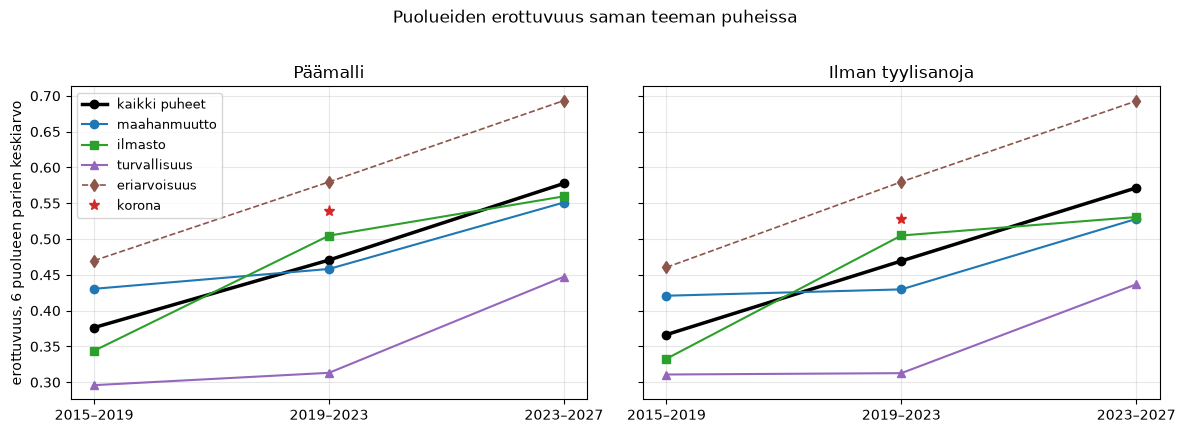

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
x = np.arange(len(KAUDET))
tyylit = {"kaikki": ("k", "o-", 2.5), "maahanmuutto": ("#1f77b4", "o-", 1.5), "ilmasto": ("#2ca02c", "s-", 1.5),
          "turvallisuus": ("#9467bd", "^-", 1.5), "eriarvoisuus": ("#8c564b", "d--", 1.2), "korona": ("#d62728", "*", 1.5)}
for j, malli in enumerate(MALLIT):
    for teema, (vari, merkki, paksuus) in tyylit.items():
        arvot = polarisaatio.loc[(MALLIT[malli], teema), KAUDET].astype(float).values
        nimi = "kaikki puheet" if teema == "kaikki" else teema
        ax[j].plot(x, arvot, merkki, color=vari, linewidth=paksuus, markersize=8 if teema == "korona" else 6, label=nimi)
    ax[j].set_xticks(x)
    ax[j].set_xticklabels([k.replace("-", "–") for k in KAUDET])
    ax[j].set_title(MALLIT[malli].capitalize())
    ax[j].grid(alpha=0.3)
ax[0].set_ylabel("erottuvuus, 6 puolueen parien keskiarvo")
ax[0].legend(loc="upper left", fontsize=9)
fig.suptitle("Puolueiden erottuvuus saman teeman puheissa", y=1.02)
fig.tight_layout()
fig.savefig(KUVAT + "teemat_erottuvuus.png", dpi=150, bbox_inches="tight")
plt.show()

### Parit teemoittain (päämalli)

Pari näytetään, jos se voidaan laskea kyseisellä kaudella.

In [8]:
paamalli = keskiarvot[keskiarvot["malli"] == "party"].copy()
paamalli["pari"] = paamalli["a"] + "–" + paamalli["b"]
taulukko = paamalli.pivot_table(index="pari", columns=["teema", "term"], values="d")
jarjestys = [a + "–" + b for a, b in PARIT]
taulukko.reindex(jarjestys)[["kaikki", "maahanmuutto", "ilmasto", "turvallisuus"]].round(2)

teema        kaikki                     maahanmuutto                      \
term      2015-2019 2019-2023 2023-2027    2015-2019 2019-2023 2023-2027   
pari                                                                       
VAS–SDP        0.08      0.20      0.46         0.09      0.13      0.63   
VAS–VIHR       0.18      0.41      0.40         0.09      0.15      0.23   
VAS–KESK       0.45      0.34      0.71         0.56      0.50      0.74   
VAS–KOK        0.31      0.39      0.75         0.37      0.40      0.82   
VAS–PS         0.34      0.56      0.76         0.50      0.67      0.79   
SDP–VIHR       0.38      0.54      0.56         0.41      0.31      0.39   
SDP–KESK       0.47      0.25      0.39         0.33      0.22      0.21   
SDP–KOK        0.39      0.40      0.49         0.41      0.35      0.31   
SDP–PS         0.46      0.67      0.62         0.57      0.71      0.60   
VIHR–KESK      0.60      0.55      0.67         0.71      0.39      0.62   
VIHR–KOK       0.47      0.65      0.70         0.54      0.56      0.76   
VIHR–PS        0.53      0.82      0.76         0.66      0.85      0.84   
KESK–KOK       0.21      0.33      0.57         0.30      0.43      0.49   
KESK–PS        0.44      0.58      0.59         0.64      0.76      0.59   
KOK–PS         0.32      0.39      0.23         0.28      0.43      0.25   

teema       ilmasto                     turvallisuus                      
term      2015-2019 2019-2023 2023-2027    2015-2019 2019-2023 2023-2027  
pari                                                                      
VAS–SDP        0.04      0.22      0.35         0.16      0.17      0.43  
VAS–VIHR       0.13      0.22      0.17         0.11      0.26      0.39  
VAS–KESK       0.42      0.47      0.78         0.55      0.35      0.69  
VAS–KOK        0.29      0.46      0.71         0.40      0.12      0.71  
VAS–PS         0.28      0.72      0.66         0.30      0.16      0.70  
SDP–VIHR       0.33      0.39      0.48         0.31      0.21      0.31  
SDP–KESK       0.33      0.29      0.38         0.32      0.23      0.16  
SDP–KOK        0.17      0.48      0.31         0.25      0.28      0.23  
SDP–PS         0.47      0.84      0.60         0.35      0.59      0.40  
VIHR–KESK      0.62      0.68      0.85         0.49      0.38      0.60  
VIHR–KOK       0.51      0.68      0.73         0.27      0.32      0.44  
VIHR–PS        0.51      0.91      0.82         0.39      0.60      0.64  
KESK–KOK       0.22      0.25      0.65         0.10      0.25      0.36  
KESK–PS        0.45      0.46      0.50         0.32      0.52      0.44  
KOK–PS         0.39      0.51      0.41         0.12      0.26      0.18

## Vertailu Twitteriin (Gronow & Malkamäki 2024)

Gronow ja Malkamäki ryhmittelivät Twitter-käyttäjät uudelleentwiittausten perusteella kolmeen ideologiseen ryhmään. Vastaavuus puolueisiin on karkea:

| Twitter-ryhmä | vastaavat puolueet tässä |
|---|---|
| Conservative Right (ConRi) | PS |
| Moderate Right (ModRi) | KOK |
| Liberal Left (LibLe) | VAS, SDP, VIHR |

KESK ei kuulu mihinkään ryhmään. Ryhmäparin erottuvuus on vastaavien puolueparien keskiarvo, esimerkiksi ConRi–LibLe = PS–VAS, PS–SDP ja PS–VIHR. Heidän aineistonsa päättyy maaliskuuhun 2023, joten vertailukelpoiset kaudet ovat 2015–19 ja 2019–23. Mittarit ovat erilaiset (retweet-verkoston E-I-indeksi vs. puheiden erottuvuus), joten vertailu koskee vain suuntia ja järjestyksiä.

In [9]:
RYHMAPARIT = {
    "ConRi–LibLe (PS vs. VAS, SDP, VIHR)": [("VAS", "PS"), ("SDP", "PS"), ("VIHR", "PS")],
    "ConRi–ModRi (PS vs. KOK)": [("KOK", "PS")],
    "ModRi–LibLe (KOK vs. VAS, SDP, VIHR)": [("VAS", "KOK"), ("SDP", "KOK"), ("VIHR", "KOK")],
}
rivit = []
for teema in ["kaikki", "maahanmuutto", "ilmasto", "turvallisuus", "korona", "eriarvoisuus"]:
    for ryhmapari, puolueparit in RYHMAPARIT.items():
        osa = paamalli[(paamalli["teema"] == teema) & paamalli[["a", "b"]].apply(tuple, axis=1).isin(puolueparit)]
        rivi = osa.groupby("term")["d"].mean()
        rivi["teema"] = teema
        rivi["ryhmäpari"] = ryhmapari
        rivit.append(rivi)
ryhmat = pd.DataFrame(rivit).set_index(["teema", "ryhmäpari"]).reindex(columns=KAUDET)
ryhmat.round(2)

term                                               2015-2019  2019-2023  \
teema        ryhmäpari                                                    
kaikki       ConRi–LibLe (PS vs. VAS, SDP, VIHR)        0.44       0.68   
             ConRi–ModRi (PS vs. KOK)                   0.32       0.39   
             ModRi–LibLe (KOK vs. VAS, SDP, VIHR)       0.39       0.48   
maahanmuutto ConRi–LibLe (PS vs. VAS, SDP, VIHR)        0.58       0.74   
             ConRi–ModRi (PS vs. KOK)                   0.28       0.43   
             ModRi–LibLe (KOK vs. VAS, SDP, VIHR)       0.44       0.44   
ilmasto      ConRi–LibLe (PS vs. VAS, SDP, VIHR)        0.42       0.82   
             ConRi–ModRi (PS vs. KOK)                   0.39       0.51   
             ModRi–LibLe (KOK vs. VAS, SDP, VIHR)       0.32       0.54   
turvallisuus ConRi–LibLe (PS vs. VAS, SDP, VIHR)        0.35       0.45   
             ConRi–ModRi (PS vs. KOK)                   0.12       0.26   
             ModRi–LibLe (KOK vs. VAS, SDP, VIHR)       0.31       0.24   
korona       ConRi–LibLe (PS vs. VAS, SDP, VIHR)         NaN       0.76   
             ConRi–ModRi (PS vs. KOK)                    NaN       0.46   
             ModRi–LibLe (KOK vs. VAS, SDP, VIHR)        NaN       0.56   
eriarvoisuus ConRi–LibLe (PS vs. VAS, SDP, VIHR)        0.55       0.80   
             ConRi–ModRi (PS vs. KOK)                   0.45       0.57   
             ModRi–LibLe (KOK vs. VAS, SDP, VIHR)       0.55       0.64   

term                                               2023-2027  
teema        ryhmäpari                                        
kaikki       ConRi–LibLe (PS vs. VAS, SDP, VIHR)        0.72  
             ConRi–ModRi (PS vs. KOK)                   0.23  
             ModRi–LibLe (KOK vs. VAS, SDP, VIHR)       0.65  
maahanmuutto ConRi–LibLe (PS vs. VAS, SDP, VIHR)        0.74  
             ConRi–ModRi (PS vs. KOK)                   0.25  
             ModRi–LibLe (KOK vs. VAS, SDP, VIHR)       0.63  
ilmasto      ConRi–LibLe (PS vs. VAS, SDP, VIHR)        0.69  
             ConRi–ModRi (PS vs. KOK)                   0.41  
             ModRi–LibLe (KOK vs. VAS, SDP, VIHR)       0.58  
turvallisuus ConRi–LibLe (PS vs. VAS, SDP, VIHR)        0.58  
             ConRi–ModRi (PS vs. KOK)                   0.18  
             ModRi–LibLe (KOK vs. VAS, SDP, VIHR)       0.46  
korona       ConRi–LibLe (PS vs. VAS, SDP, VIHR)         NaN  
             ConRi–ModRi (PS vs. KOK)                    NaN  
             ModRi–LibLe (KOK vs. VAS, SDP, VIHR)        NaN  
eriarvoisuus ConRi–LibLe (PS vs. VAS, SDP, VIHR)        0.81  
             ConRi–ModRi (PS vs. KOK)                   0.31  
             ModRi–LibLe (KOK vs. VAS, SDP, VIHR)       0.77

## Tulkinta

**1. Puolueet erottuvat yhä selvemmin myös saman teeman puheissa.** Erottuvuus kasvaa kaikissa teemoissa (maahanmuutto 0,42 → 0,55, ilmasto 0,34 → 0,56, turvallisuus 0,30 → 0,45), ja taso on suunnilleen sama kuin kaikissa puheissa (0,37 → 0,58). Kasvu ei siis johdu vain aiheiden omistajuudesta: puolueet puhuvat samasta asiasta yhä eri tavalla. Osa erosta voi olla roolia (hallitus puolustaa, oppositio arvostelee). Ilman tyylisanoja luvut ovat enintään 0,03 pienempiä.

**2. Teemojen erot ovat järkeviä.** Turvallisuus on vähiten jakava teema kahdella ensimmäisellä kaudella (Nato- ja puolustuskeskustelun yhteisymmärrys). Ilmasto jakautuu eniten kaudella 2019–23, ja maahanmuutto on jakava jo 2015–19. Eriarvoisuus (lähinnä verot) erottaa eniten, mutta teema on hakusanoiltaan väljä.

**3. Vertailu Twitteriin: suunnat täsmäävät.**
- *Ilmasto:* PS:n ja vasemmisto-vihreiden ero kaksinkertaistuu 2019–23 (0,42 → 0,82); Twitterissä ilmasto alkoi polarisoitua 2019. Selvin yhtymäkohta.
- *Maahanmuutto:* PS erottuu vasemmisto-vihreistä eniten jo 2015–19, ja KOK on vasemmisto-vihreitä lähempänä kuin PS; Twitterissä ModRi asettui usein LibLe:n puolelle.
- *Eriarvoisuus:* PS–KOK on ryhmäpareista pienin joka kaudella, kuten ConRi–ModRi Twitterissä.
- *Turvallisuus:* yhtymäkohta on heikompi.

Kaudella 2023–27, jota Twitter-aineisto ei kata, kasvu tulee KOK:n ja vasemmisto-vihreiden erosta (0,48 → 0,65), kun hallituskumppanit PS ja KOK lähenevät (0,39 → 0,23).

**Avoin kysymys:** kaksi suurta muutosta, joita puheiden sisältöä lukemalla voisi selittää: VAS ja SDP puhuvat maahanmuutosta hyvin eri tavalla 2023–27 (0,13 → 0,63), vaikka molemmat ovat oppositiossa; KESK ja KOK ilmastosta (0,25 → 0,65).

**Rajoitukset:** Twitter-ryhmät eivät ole puolueita (vastaavuus on oma oletuksemme), mittarit ovat erilaiset, hakusanat ovat karkeita, eivätkä RKP ja KD ole mukana.

## Liite: erottuvuus puheen pituuden mukaan

Luokittelija arvaa puolueen yhdestä puheesta, joten pitkä puhe on helpompi tunnistaa kuin lyhyt. Tarkistus muistion 07 osioon 1: erottuvuus (8 puoluetta, 28 paria) lasketaan erikseen eripituisille puheille samoista testiennusteista. Tulos tallennetaan tiedostoon `results/pituus_erottuvuus.csv`.

In [10]:
pituudet = pd.read_parquet(KANSIO + "counts_index.parquet", columns=["speech_id", "n_tokens"])
pituusdata = ennusteet["party"].merge(pituudet, on="speech_id")
PITUUSLUOKAT = ["alle 50", "50–100", "100–200", "yli 200"]
pituusdata["pituus"] = pd.cut(pituusdata["n_tokens"], [0, 50, 100, 200, 100000], labels=PITUUSLUOKAT)

rivit = []
for (kausi, pituus, toisto), osa in pituusdata.groupby(["term", "pituus", "rep"], observed=True):
    erot = []
    for a, b in combinations(config.MAIN_PARTIES, 2):
        pari = osa[osa["label"].isin([a, b])]
        if (pari["label"] == a).sum() < 20 or (pari["label"] == b).sum() < 20:
            continue
        pisteet = np.log(np.clip(pari["p_" + a], 1e-12, 1)) - np.log(np.clip(pari["p_" + b], 1e-12, 1))
        erot.append(2 * roc_auc_score(pari["label"] == a, pisteet) - 1)
    rivit.append({"term": kausi, "length": pituus, "rep": toisto, "d": np.mean(erot)})
pituustulos = pd.DataFrame(rivit).groupby(["term", "length"], observed=True)["d"].mean().reset_index()
mediaanit = pituusdata.drop_duplicates("speech_id").groupby("term")["n_tokens"].median()
pituustulos["median_length"] = pituustulos["term"].map(mediaanit)
pituustulos.to_csv(TULOKSET + "pituus_erottuvuus.csv", index=False)
pituustulos.pivot(index="length", columns="term", values="d").reindex(PITUUSLUOKAT).round(2)

term,2015-2019,2019-2023,2023-2027
length,,,
alle 50,0.27,0.25,0.42
50–100,0.35,0.41,0.52
100–200,0.39,0.41,0.50
yli 200,0.45,0.50,0.63
